# Reconstruct just one "target segment" in the target image.

For each n-point-probe, we count the number of times the points hit the target segment. We train a model to estimate the probability that each pixels belongs to the target segment. If there are only two segments (foreground, background) then this yields a complete segmentation.

Here we test a new model written by Gemini, and show Gemini's reasoning in advance of writing the code.

*italicized text*

## Gemini's reasoning and code

### My prompt:

> Suppose we have a probabilistic image segmentation $S$ that depicts $k$ segments. $S$ is an image with $h \times w$ pixels. Each pixel hosts a probability distribution that specifies the probability that each of $k$ segments occupies the pixel. Now suppose we sample $n$ pixels from the image. What is the probability that $0 \leq r \leq n$ of the $n$ sampled pixels touch a target segment, $v$?






### Gemini's answer

Each sampled pixel $j \in \{1, \dots, n\}$ is an independent Bernoulli trial with success probability $p_j = p_v(x_j)$. The total count $R_v$ is the sum of these non-identically distributed Bernoulli random variables:

$$R_v = \sum_{j=1}^{n} Y_j, \quad Y_j \sim \text{Bernoulli}(p_j)$$

Evaluating $P(R_v = r)$ using the direct combinatorial definition requires iterating over all $\binom{n}{r}$ subsets of size $r$:

$$P(R_v = r) = \sum_{\vert{}A\vert{}=r} \left( \prod_{j \in A} p_j \right) \left( \prod_{k \notin A} (1 - p_k) \right)$$

For $n = 30$, $\binom{30}{15} \approx 155 \text{ million}$ terms. For $n = 100$, calculating this directly is completely intractable.

We can use dynamic programming to make the computations more tractable.

First, we define a subproblem state:

$$\text{DP}[i, k] = \text{Probability of observing } k \text{ hits considering only the first } i \text{ sampled pixels}$$

where $i \in \{0, 1, \dots, n\}$ and $k \in \{0, 1, \dots, i\}$.

#### 1. Base Case ($i = 0$)

Before observing any pixels ($i = 0$), there are 0 hits with probability 1:

$$\text{DP}[0, 0] = 1.0, \quad \text{DP}[0, k] = 0 \text{ for } k > 0$$

#### 2. Transition Relation ($i \to i + 1$)

When considering the $(i+1)$-th pixel with probability $p_{i+1}$:

* **Case A (Pixel $i+1$ is NOT target):** Occurs with probability $(1 - p_{i+1})$. The count remains $k$, which required $k$ hits from the first $i$ pixels.
* **Case B (Pixel $i+1$ IS target):** Occurs with probability $p_{i+1}$. The count becomes $k$, which required $k-1$ hits from the first $i$ pixels.

This gives the recurrence relation:

$$\text{DP}[i+1, k] = \underbrace{\text{DP}[i, k] \cdot (1 - p_{i+1})}_{\text{pixel } i+1 \text{ is not target}} + \underbrace{\text{DP}[i, k-1] \cdot p_{i+1}}_{\text{pixel } i+1 \text{ is target}}$$



## My comments

* $P(R_v = r)$ is obviously differentiable. Thus, given a training set of $n$-point probe and the corresponding counts $r$, so we can use SGD to optmize the target segment of the underlyaing probabilistic segment. In the case where there are only 2 segments, that's all we need to do!

* Gemini wrote an efficient algorithm for computing $P(R_v = r)$, as you can see above (another case of AI being smarter than me).

* You can see below that if we select a $25 \times 25$ probing grid (over a $400 \times 400$ display resolution) we can get basically perfect (overfit) reconstructions of the target segment when we have around $250$ training samples and $n = 3$ or $n = 4$.

* Probe generation is currently really basic. The GridProbeGenerator makes sure that every pixel on the grid is touched at least once (assuming we select enough trials) and that no probe contains redundant more than one of the same point. For a $25 \times 25$ sampling grid and $n=4$, we need $25^2 / 4 \approx 157$ trials to make sure that every point on the grid is included in at least one probe. In practice it seems you need more than that bare minimum number of trials to get decent reconstructions of the most complex curve -- test it and see for yourself.

* You can see that, with this probe generation approach, the distribution of counts is really non-uniform; if we balance it out we may get more sample efficiency, meaning that it might be possible to obtain perfect (overfit) reconstructions with the bare minimum number of trials.








## Build a simulated dataset to test the code

In [2]:
# !pip install git+https://github.com/nase0005/n-point-probes-.git
##grab updated repo
!pip install --upgrade --force-reinstall -q git+https://github.com/nase0005/n-point-probes-.git

import probes_experiment as pe
import utils
import models
import torch
import torch.nn as nn
from torch.optim import SGD

##bindings
from utils import load_target_images_from_directory, extract_segment_count_from_filename, sample_grid_map, downsample_data_bundle
from models import LaplacianSmoothnessLoss, TargetHitsNet, PoissonBinomialPMF

  Preparing metadata (setup.py) ... done


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

#mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Automatically picks CUDA (GPU) if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


In [18]:
# Run workflow
experiment_id = "calibrate_curve_recons"
base_dir = Path("/content/drive/MyDrive/imagery_psychophysics/cloud-of-point-probes/data/")
workspace = base_dir / "experiments" / experiment_id
target_images = load_target_images_from_directory(base_dir / "squiggle_pics")

num_vision_trials = 256
num_imagery_trials = 0
sampling_policy = pe.ProbeSubsetPolicy.IMAGERY_SUBSET_OF_VISION
randomization_seed = 67
curve_segment_id = 1
metrics = ["target_object_hits"] ##see ProbeMaskAnalyzer for choices
grid_shape = (25, 25) # Increased grid resolution to ensure more even spacing
points_per_probe = 4 # Reduced points per probe to avoid loss during downsampling


for target_image in target_images:
    n_segments = extract_segment_count_from_filename(target_image.name, default=4)
    pe.TargetSegmenter.segment_kmeans(target_image, n_clusters=n_segments)

configs = [pe.RunConfig(img, num_vision_trials=num_vision_trials, num_imagery_trials=num_imagery_trials) for img in target_images]

exp = pe.Experiment.create(
    experiment_id=experiment_id,
    run_configs=configs,
    root_dir=workspace,
    probe_color=(255, 105, 180, 255),
    probe_radius=6,
    bg_color=(10, 10, 10, 255),
)

generator = pe.GridProbeGenerator(grid_shape=grid_shape, points_per_probe=points_per_probe)
for run in exp.runs:
    generator.assign_probes_to_run(run, policy=sampling_policy, seed=randomization_seed)


pe.ProbeMaskAnalyzer.evaluate_experiment_results(
    experiment=exp,
    metrics=metrics,
    target_segment_id=curve_segment_id,
)

if exp.validate():
    vec_dict = exp.to_data_bundle()
    my_data = downsample_data_bundle(vec_dict, inplace = False)

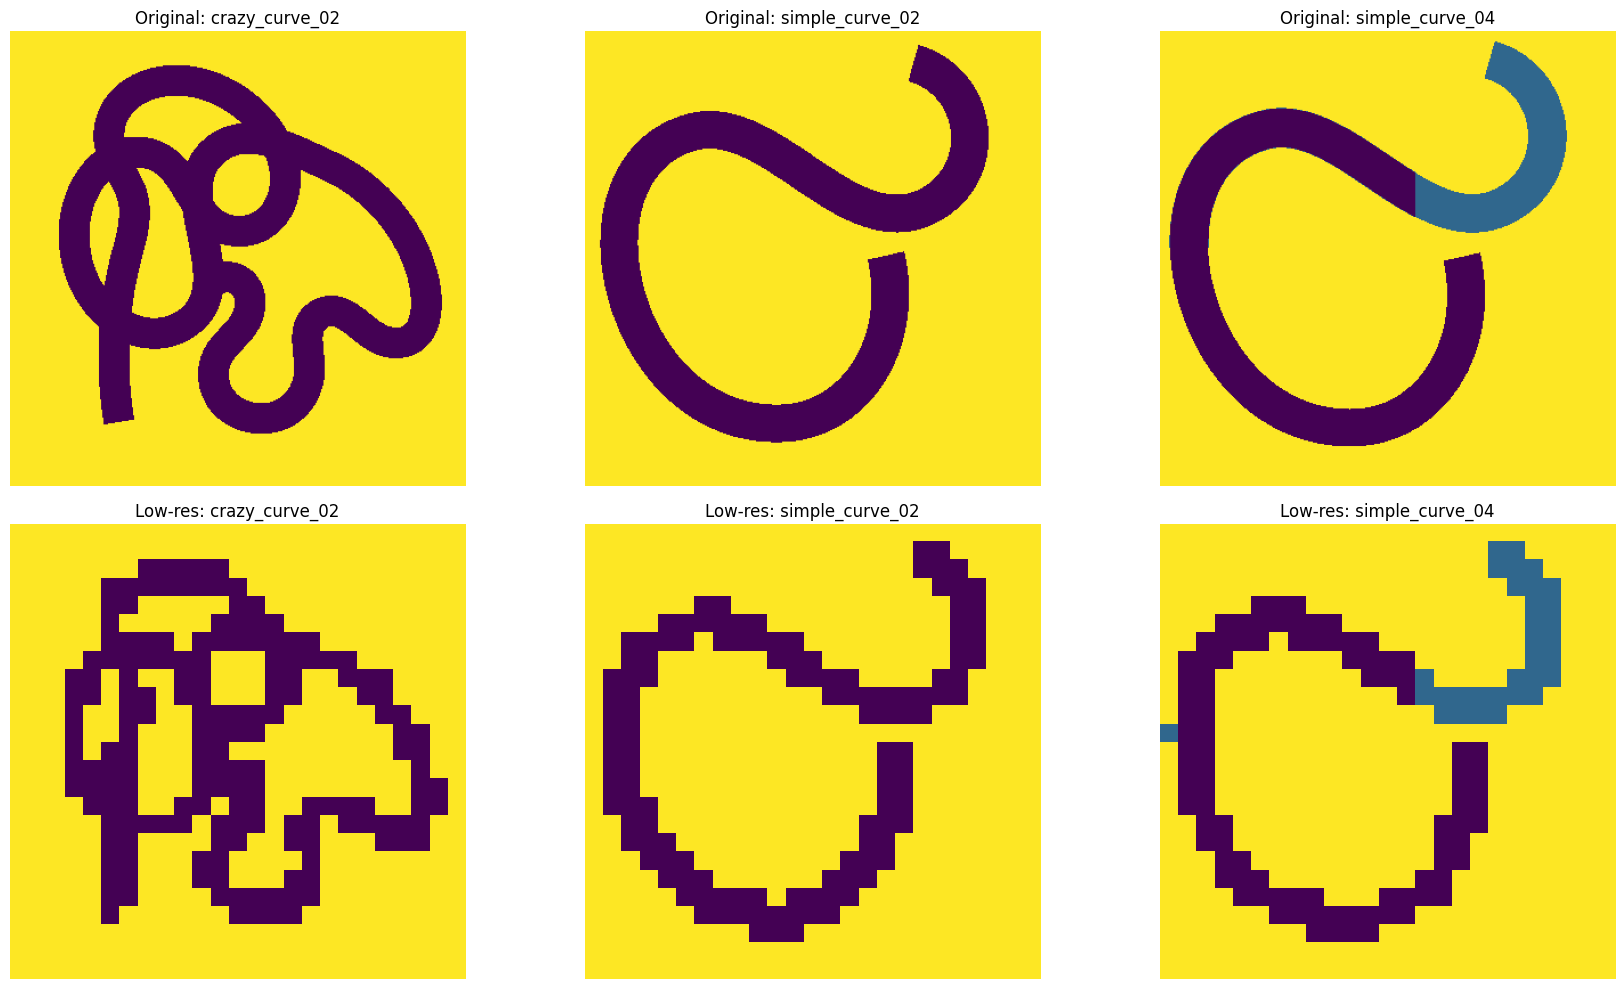

In [19]:
num_images = len(vec_dict)

fig, axes = plt.subplots(2, num_images, figsize=(6 * num_images, 10))

# Ensure axes is always a 2D array, even if num_images is 1
if num_images == 1:
    axes = np.array([axes]).reshape(2, 1)

for i, (image_name, original_data) in enumerate(vec_dict.items()):
    original_rgba = original_data['target_assets']['label_map']
    low_res_rgba = my_data[image_name]['target_assets']['label_map']

    # Top row: Original images
    axes[0, i].imshow(original_rgba)
    axes[0, i].set_title(f'Original: {image_name}')
    axes[0, i].axis('off')

    # Bottom row: Low-resolution images
    axes[1, i].imshow(low_res_rgba)
    axes[1, i].set_title(f'Low-res: {image_name}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

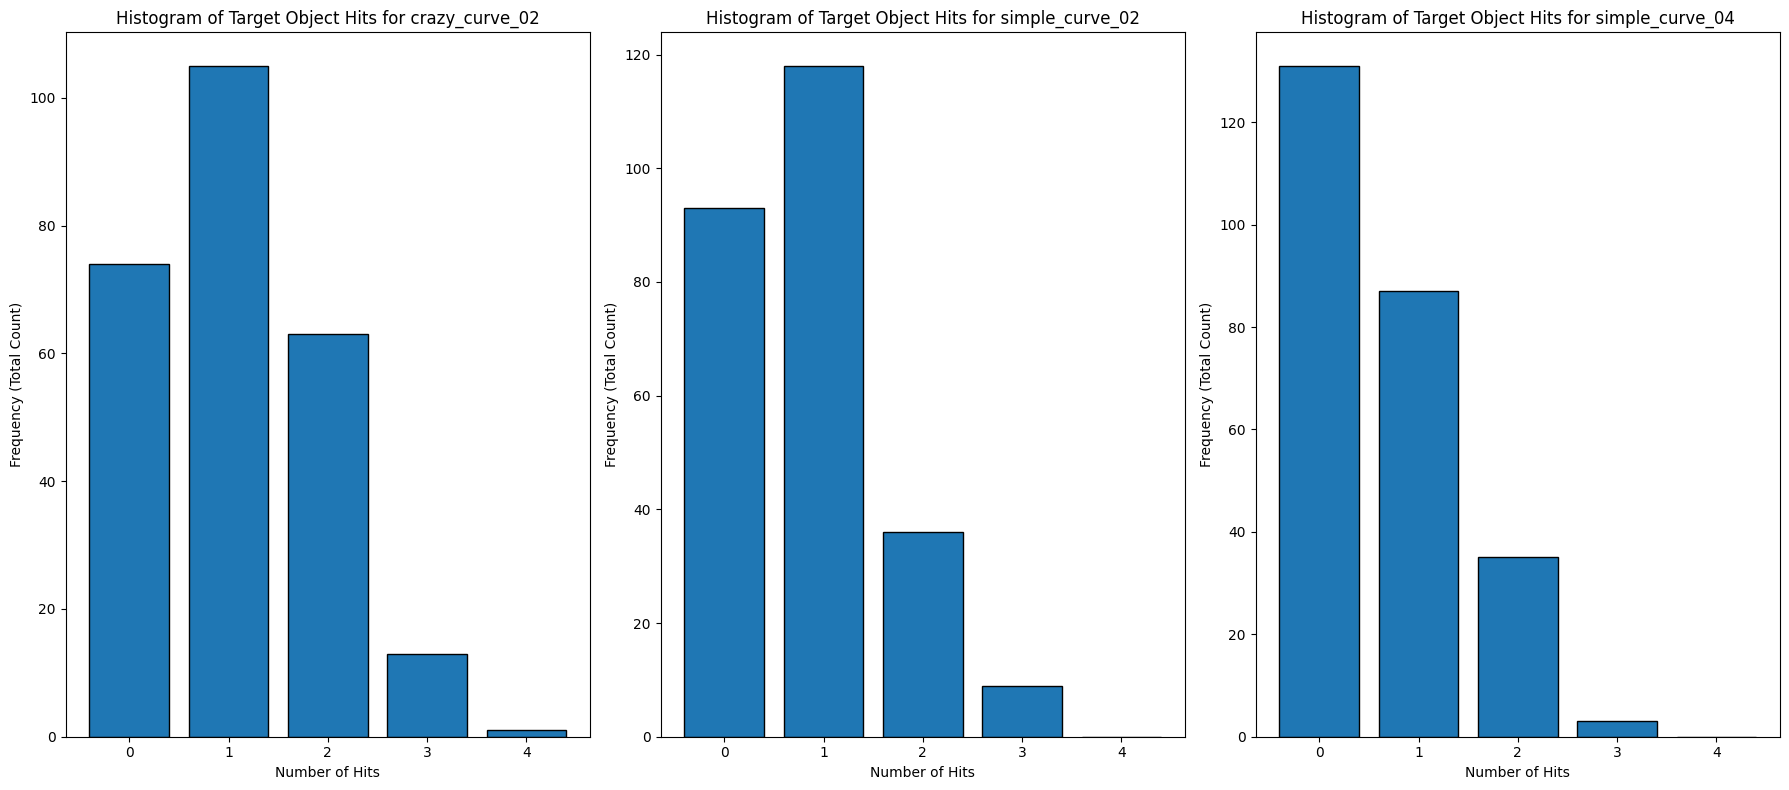

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

num_images = len(my_data)

# Find the maximum count across all images to set consistent binning
max_count_overall = 0
for image_name, data in my_data.items():
    # Ensure data exists and is not empty before attempting to find max
    if 'vision' in data and 'results' in data['vision'] and 'target_obj_1_hits' in data['vision']['results']:
        # Removed .cpu() as target_obj_1_hits is already a numpy array
        count_data_np = data['vision']['results']['target_obj_1_hits']
        if len(count_data_np) > 0:
            max_count_overall = max(max_count_overall, np.max(count_data_np))

# Define bins to center bars on integer count values
# For counts 0, 1, 2, ..., N, bin edges should be -0.5, 0.5, 1.5, ..., N+0.5
bins = np.arange(-0.5, max_count_overall + 1.5, 1)

# Arrange plots horizontally (1 row, num_images columns)
fig, axes = plt.subplots(1, num_images, figsize=(6 * num_images, 8)) # Adjusted figsize for horizontal layout

# Ensure axes is always an iterable (1D array) even if num_images is 1
if num_images == 1:
    axes = [axes]

for i, (image_name, data) in enumerate(my_data.items()):
    ax = axes[i]
    # Extract count data and convert to numpy
    count_data_np = data['vision']['results']['target_obj_1_hits']

    # Plot histogram
    ax.hist(count_data_np, bins=bins, edgecolor='black', rwidth=0.8)
    ax.set_title(f'Histogram of Target Object Hits for {image_name}')
    ax.set_xlabel('Number of Hits')
    ax.set_ylabel('Frequency (Total Count)')

    # Set integer ticks on the x-axis for better readability
    ax.set_xticks(np.arange(0, max_count_overall + 1, 1))

plt.tight_layout()
plt.show()

In [21]:
all_image_loss_histories = {}
# Dictionary to store all trained learning_net models
all_trained_models = {}

LR = 10.
NUM_EPOCHS = 1000
ENERGY_WEIGHT = .5

for image_name, data in my_data.items():
    all_image_loss_histories[image_name] = []
    print(f"\nProcessing image: {image_name}")
    K = my_data[image_name]['target_assets']['num_segments']
    H, W = my_data[image_name]['target_assets']['dimensions'].values()
    count_data = my_data[image_name]['vision']['results']['target_obj_1_hits']
    probes = my_data[image_name]['vision']['probes']['points_px']

    ##torchify count_data and probes
    count_data = torch.from_numpy(count_data).long() # Convert to float
    probes = torch.from_numpy(probes).long() # Convert to float, as probes might also need it

    ##put count_data and probes on device
    count_data = count_data.to(device)
    probes = probes.to(device)


    # Instantiate model, loss, and exponentiated-gradient equivalent optimizer
    model = TargetHitsNet(height=H, width=W, num_segments=K)
    loss_fn = PoissonBinomialPMF()  ##this is where we compute $P(R_v = r)$
    lps = LaplacianSmoothnessLoss() ##this smooths out the reconstructions -- a small amount seems to help a lot

    # SGD on Softmax logits corresponds to Exponentiated Gradient updates on p
    optimizer = SGD(model.parameters(), lr=LR)


    for epoch in range(NUM_EPOCHS):
        # 2. Reset gradients
        optimizer.zero_grad()

        # 3. Forward pass
        p_v_sampled = model(probes, target_segment=curve_segment_id)

        # 4. Compute Loss
        log_likelihood = loss_fn(p_v_sampled, count_data)
        loss = -log_likelihood.mean()
        # Add a batch dimension to the probabilities before passing to LaplacianSmoothnessLoss
        energy = lps(model.get_probabilities().unsqueeze(0))
        loss += ENERGY_WEIGHT*energy
        all_image_loss_histories[image_name].append(loss.item())

        # 5. Backward pass & step
        loss.backward()
        optimizer.step()

        # Logging progress
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Loss: {loss.item():.4f}")

    print(f"Training for {image_name} completed. Final loss: {loss:.4f}")

    # Store the trained model in the dictionary
    all_trained_models[image_name] = model
    print(f"Model for {image_name} stored in 'all_trained_models' dictionary.")


Processing image: crazy_curve_02
Epoch [20/1000] - Loss: 1.1459
Epoch [40/1000] - Loss: 0.9603
Epoch [60/1000] - Loss: 0.8650
Epoch [80/1000] - Loss: 0.7992
Epoch [100/1000] - Loss: 0.7461
Epoch [120/1000] - Loss: 0.7001
Epoch [140/1000] - Loss: 0.6588
Epoch [160/1000] - Loss: 0.6207
Epoch [180/1000] - Loss: 0.5849
Epoch [200/1000] - Loss: 0.5512
Epoch [220/1000] - Loss: 0.5200
Epoch [240/1000] - Loss: 0.4917
Epoch [260/1000] - Loss: 0.4662
Epoch [280/1000] - Loss: 0.4434
Epoch [300/1000] - Loss: 0.4229
Epoch [320/1000] - Loss: 0.4044
Epoch [340/1000] - Loss: 0.3877
Epoch [360/1000] - Loss: 0.3727
Epoch [380/1000] - Loss: 0.3593
Epoch [400/1000] - Loss: 0.3476
Epoch [420/1000] - Loss: 0.3373
Epoch [440/1000] - Loss: 0.3283
Epoch [460/1000] - Loss: 0.3201
Epoch [480/1000] - Loss: 0.3127
Epoch [500/1000] - Loss: 0.3060
Epoch [520/1000] - Loss: 0.3001
Epoch [540/1000] - Loss: 0.2949
Epoch [560/1000] - Loss: 0.2903
Epoch [580/1000] - Loss: 0.2861
Epoch [600/1000] - Loss: 0.2823
Epoch [620

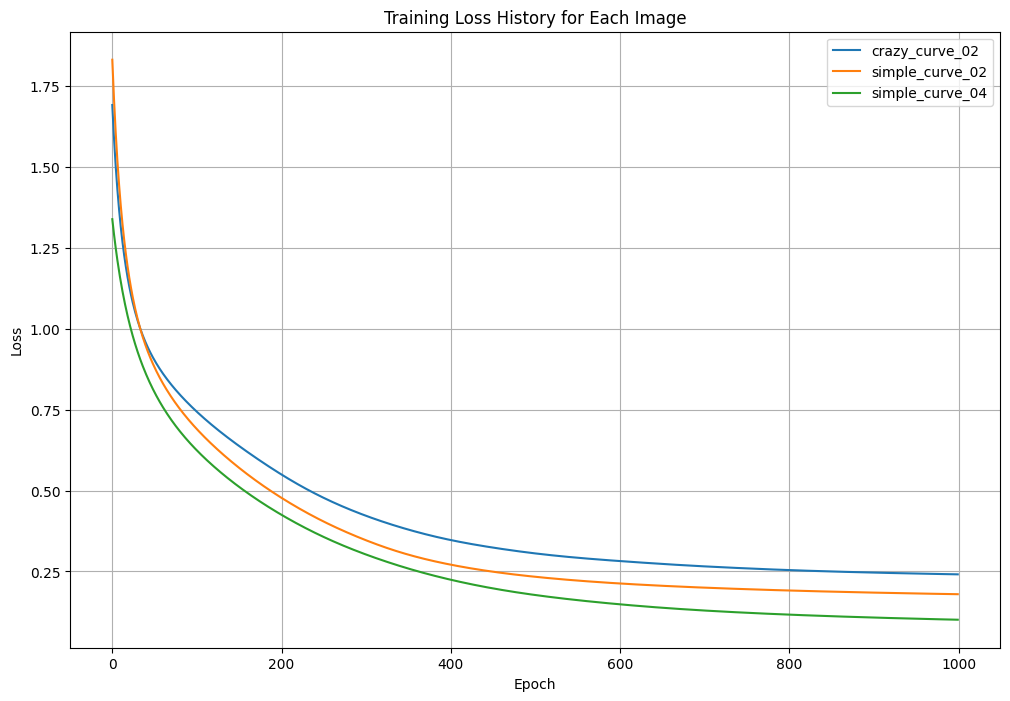

In [22]:
plt.figure(figsize=(12, 8))
for image_name, loss_history in all_image_loss_histories.items():
    plt.plot(loss_history, label=image_name)

plt.title('Training Loss History for Each Image')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

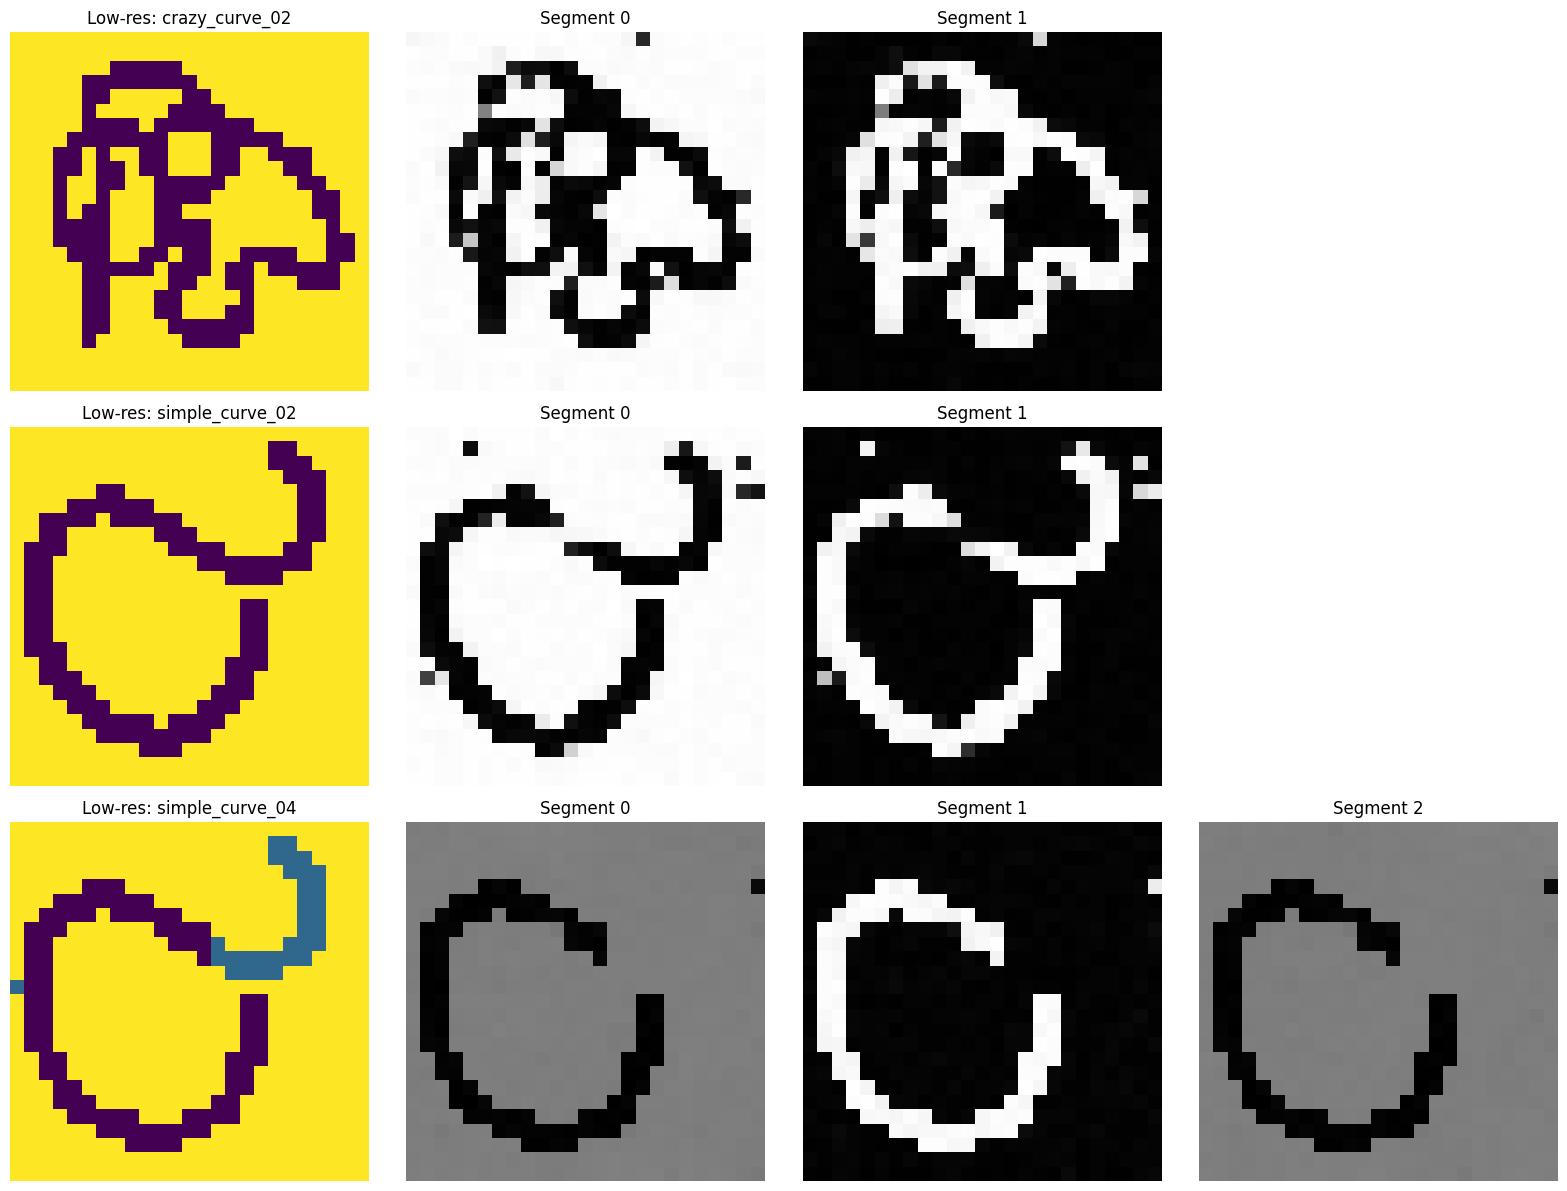

In [23]:
import math

num_models = len(all_trained_models)

# Determine the maximum number of segments across all models for consistent subplot sizing
max_segments = 0
for image_name, model in all_trained_models.items():
    max_segments = max(max_segments, model.num_segments)

# Total number of columns will be max_segments + 1 (for the low-res image)
num_display_cols = max_segments + 1
fig, axes = plt.subplots(num_models, num_display_cols, figsize=(4 * num_display_cols, 4 * num_models))

# Ensure axes is always a 2D array, even if there's only one model or one segment
if num_models == 1 and num_display_cols == 1:
    axes = np.array([[axes]])
elif num_models == 1:
    axes = np.array([axes])
elif num_display_cols == 1:
    axes = np.array(axes).reshape(-1, 1)


for i, (image_name, model) in enumerate(all_trained_models.items()):
    probs = model.get_probabilities().detach().cpu().numpy()  # (k, h, w)
    k_segments = probs.shape[0]

    # Get low-resolution image
    low_res_rgba = my_data[image_name]['target_assets']['label_map']

    # Plot the low-resolution target image in the first column
    ax_first = axes[i, 0]
    ax_first.imshow(low_res_rgba)
    ax_first.set_title(f'Low-res: {image_name}')
    ax_first.axis('off')

    for j in range(max_segments): # Loop through segments (0 to max_segments-1)
        ax = axes[i, j + 1] # Shift segment plots to column 1 onwards

        if j < k_segments:
            # Display the probability map for the current segment
            im = ax.imshow(probs[j], cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'Segment {j}') # No need for image_name again here
        else:
            # Hide unused subplots for models with fewer segments
            fig.delaxes(ax)

        ax.axis('off') # Turn off axes for cleaner visualization

plt.tight_layout()
plt.show()